### Fase 1: Fine-Tuning de VGG16 (chinelos x tênis)

**Vídeo de demonstração:** [colar aqui o link do YouTube, "Não listado", depois de gravar]

Machine Learning II - PUCRS

In [7]:
import os
import hashlib
from pathlib import Path

import torch
from PIL import Image

if Path.cwd().name == "notebooks":
    os.chdir("..")

print("pasta de trabalho:", Path.cwd())

pasta de trabalho: c:\Users\Marcel Albuquerque\Documents\1. Atividades\PUCRS - 2026.3 - Machine Learning II\2026.3-machine-learning-ii


#### Verificação do ambiente

In [8]:
print("PyTorch:", torch.__version__)
print("GPU disponível:", torch.cuda.is_available())
print("data/raw existe?", Path("data/raw").exists())

PyTorch: 2.13.0+cpu
GPU disponível: False
data/raw existe? True


#### Coleta e organização do dataset

In [9]:
RAW_DIR = Path("data/raw")
OUT_DIR = Path("data/processed")
TAMANHO = (250, 250)
CLASSES = ["chinelo", "tenis"]


def hash_arquivo(caminho: Path) -> str:
    return hashlib.md5(caminho.read_bytes()).hexdigest()


for classe in CLASSES:
    origem = RAW_DIR / classe
    destino = OUT_DIR / classe
    destino.mkdir(parents=True, exist_ok=True)

    hashes_vistos = set()
    contador = 0

    for arquivo in sorted(origem.glob("*.*")):
        h = hash_arquivo(arquivo)
        if h in hashes_vistos:
            print(f"duplicada ignorada: {arquivo.name}")
            continue
        hashes_vistos.add(h)

        with Image.open(arquivo) as img:
            img = img.convert("RGB")
            img = img.resize(TAMANHO, Image.LANCZOS)
            contador += 1
            nome_final = f"{classe}_{contador:03d}.jpg"
            img.save(destino / nome_final, "JPEG", quality=90)

    print(f"{classe}: {contador} imagens processadas")

duplicada ignorada: Chinelo_35.jpg
duplicada ignorada: Chinelo_36.jpg
chinelo: 53 imagens processadas
tenis: 55 imagens processadas


##### Fonte do dataset

As imagens foram coletadas manualmente através de buscas no Google
Imagens, uma a uma, sem uso de dataset pronto

Total coletado: 53 imagens de chinelo, 55 imagens de tênis.

#### Pré-processamento com torchvision

In [10]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

dataset_completo = datasets.ImageFolder("data/processed", transform=transform)
print("classes:", dataset_completo.class_to_idx)
print("total de imagens:", len(dataset_completo))

classes: {'chinelo': 0, 'tenis': 1}
total de imagens: 108


##### Split treino/validação

In [11]:
tamanho_treino = int(0.8 * len(dataset_completo))
tamanho_val = len(dataset_completo) - tamanho_treino
gerador = torch.Generator().manual_seed(42)
treino_ds, val_ds = random_split(
    dataset_completo, [tamanho_treino, tamanho_val], generator=gerador
)

train_loader = DataLoader(treino_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

print(f"treino: {len(treino_ds)} imagens | validação: {len(val_ds)} imagens")

treino: 86 imagens | validação: 22 imagens


##### Conferindo visualmente se os rótulos batem

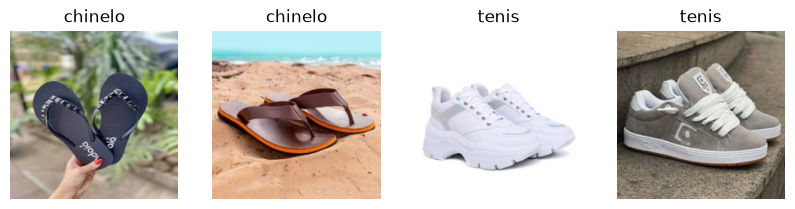

In [12]:
import matplotlib.pyplot as plt
import numpy as np

classes = dataset_completo.classes
indices = [0, 1, len(dataset_completo) // 2, len(dataset_completo) // 2 + 1]

fig, eixos = plt.subplots(1, len(indices), figsize=(10, 3))
for eixo, idx in zip(eixos, indices):
    img, rotulo = dataset_completo[idx]
    img_np = img.permute(1, 2, 0).numpy() * np.array(IMAGENET_STD) + np.array(
        IMAGENET_MEAN
    )
    eixo.imshow(img_np.clip(0, 1))
    eixo.set_title(classes[rotulo])
    eixo.axis("off")
plt.show()

#### Fine-Tuning da VGG16

##### Carregar o modelo pré-treinado

In [13]:
import torch.nn as nn
from torchvision.models import vgg16, VGG16_Weights

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

modelo = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

device: cpu
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\Marcel Albuquerque/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100.0%


##### Congelar as camadas convolucionais

In [14]:
for parametro in modelo.features.parameters():
    parametro.requires_grad = False

##### Trocar classificação para saída binária

In [15]:
modelo.classifier[6] = nn.Linear(4096, 1)
modelo = modelo.to(device)

parametros_treinaveis = [p for p in modelo.parameters() if p.requires_grad]
print(f"parâmetros treináveis: {sum(p.numel() for p in parametros_treinaveis)}")

parâmetros treináveis: 119549953


##### loss e otimizador

In [16]:
criterio = nn.BCEWithLogitsLoss()
otimizador = torch.optim.Adam(parametros_treinaveis, lr=1e-4)

#### Treinamento com TensorBoard

In [17]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(log_dir="runs/fase1_vgg16_finetuning")


def roda_epoca(loader, treinando: bool):
    modelo.train() if treinando else modelo.eval()
    perda_total, acertos, total = 0.0, 0, 0

    with torch.set_grad_enabled(treinando):
        for imagens, rotulos in loader:
            imagens = imagens.to(device)
            rotulos = rotulos.float().unsqueeze(1).to(device)

            if treinando:
                otimizador.zero_grad()

            saidas = modelo(imagens)
            perda = criterio(saidas, rotulos)

            if treinando:
                perda.backward()
                otimizador.step()

            perda_total += perda.item() * imagens.size(0)
            predicoes = (torch.sigmoid(saidas) > 0.5).float()
            acertos += (predicoes == rotulos).sum().item()
            total += imagens.size(0)

    return perda_total / total, acertos / total

##### Loop de treino que efetivamente roda as épocas

In [18]:
NUM_EPOCAS = 15
for epoca in range(NUM_EPOCAS):
    loss_treino, acc_treino = roda_epoca(train_loader, treinando=True)
    loss_val, acc_val = roda_epoca(val_loader, treinando=False)

    writer.add_scalar("Loss/train", loss_treino, epoca)
    writer.add_scalar("Loss/val", loss_val, epoca)
    writer.add_scalar("Accuracy/train", acc_treino, epoca)
    writer.add_scalar("Accuracy/val", acc_val, epoca)

    print(
        f"época {epoca+1}/{NUM_EPOCAS} | "
        f"loss treino {loss_treino:.4f} acc treino {acc_treino:.3f} | "
        f"loss val {loss_val:.4f} acc val {acc_val:.3f}"
    )

writer.close()

época 1/15 | loss treino 0.6075 acc treino 0.663 | loss val 0.3235 acc val 0.955
época 2/15 | loss treino 0.1667 acc treino 0.965 | loss val 0.1762 acc val 1.000
época 3/15 | loss treino 0.0473 acc treino 1.000 | loss val 0.1116 acc val 1.000
época 4/15 | loss treino 0.0080 acc treino 1.000 | loss val 0.0822 acc val 1.000
época 5/15 | loss treino 0.0017 acc treino 1.000 | loss val 0.0763 acc val 1.000
época 6/15 | loss treino 0.0004 acc treino 1.000 | loss val 0.0816 acc val 0.955
época 7/15 | loss treino 0.0004 acc treino 1.000 | loss val 0.0865 acc val 0.909
época 8/15 | loss treino 0.0001 acc treino 1.000 | loss val 0.0904 acc val 0.909
época 9/15 | loss treino 0.0001 acc treino 1.000 | loss val 0.0942 acc val 0.909
época 10/15 | loss treino 0.0001 acc treino 1.000 | loss val 0.0952 acc val 0.909
época 11/15 | loss treino 0.0000 acc treino 1.000 | loss val 0.0930 acc val 0.909
época 12/15 | loss treino 0.0000 acc treino 1.000 | loss val 0.0930 acc val 0.909
época 13/15 | loss treino

#### Treinamento com acompanhamento via TensorBoard

In [19]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(log_dir="runs/fase1_vgg16_finetuning")


def roda_epoca(loader, treinando: bool):
    modelo.train() if treinando else modelo.eval()
    perda_total, acertos, total = 0.0, 0, 0

    with torch.set_grad_enabled(treinando):
        for imagens, rotulos in loader:
            imagens = imagens.to(device)
            rotulos = rotulos.float().unsqueeze(1).to(device)

            if treinando:
                otimizador.zero_grad()

            saidas = modelo(imagens)
            perda = criterio(saidas, rotulos)

            if treinando:
                perda.backward()
                otimizador.step()

            perda_total += perda.item() * imagens.size(0)
            predicoes = (torch.sigmoid(saidas) > 0.5).float()
            acertos += (predicoes == rotulos).sum().item()
            total += imagens.size(0)

    return perda_total / total, acertos / total


NUM_EPOCAS = 15
for epoca in range(NUM_EPOCAS):
    loss_treino, acc_treino = roda_epoca(train_loader, treinando=True)
    loss_val, acc_val = roda_epoca(val_loader, treinando=False)

    writer.add_scalar("Loss/train", loss_treino, epoca)
    writer.add_scalar("Loss/val", loss_val, epoca)
    writer.add_scalar("Accuracy/train", acc_treino, epoca)
    writer.add_scalar("Accuracy/val", acc_val, epoca)

    print(
        f"época {epoca+1}/{NUM_EPOCAS} | "
        f"loss treino {loss_treino:.4f} acc treino {acc_treino:.3f} | "
        f"loss val {loss_val:.4f} acc val {acc_val:.3f}"
    )

writer.close()

época 1/15 | loss treino 0.0000 acc treino 1.000 | loss val 0.0911 acc val 0.909
época 2/15 | loss treino 0.0000 acc treino 1.000 | loss val 0.0909 acc val 0.909
época 3/15 | loss treino 0.0000 acc treino 1.000 | loss val 0.0904 acc val 0.909
época 4/15 | loss treino 0.0000 acc treino 1.000 | loss val 0.0892 acc val 0.909
época 5/15 | loss treino 0.0000 acc treino 1.000 | loss val 0.0890 acc val 0.909
época 6/15 | loss treino 0.0000 acc treino 1.000 | loss val 0.0900 acc val 0.909
época 7/15 | loss treino 0.0000 acc treino 1.000 | loss val 0.0900 acc val 0.909
época 8/15 | loss treino 0.0000 acc treino 1.000 | loss val 0.0887 acc val 0.909
época 9/15 | loss treino 0.0000 acc treino 1.000 | loss val 0.0894 acc val 0.909
época 10/15 | loss treino 0.0000 acc treino 1.000 | loss val 0.0936 acc val 0.909
época 11/15 | loss treino 0.0000 acc treino 1.000 | loss val 0.0994 acc val 0.909
época 12/15 | loss treino 0.0000 acc treino 1.000 | loss val 0.1056 acc val 0.909
época 13/15 | loss treino

##### Visualizando no TensorBoard

#### Avaliação dos resultados

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

modelo.eval()
todos_rotulos, todas_predicoes = [], []

with torch.no_grad():
    for imagens, rotulos in val_loader:
        imagens = imagens.to(device)
        saidas = modelo(imagens)
        predicoes = (torch.sigmoid(saidas) > 0.5).float().cpu().squeeze(1)
        todas_predicoes.extend(predicoes.tolist())
        todos_rotulos.extend(rotulos.tolist())

print("Acurácia:", accuracy_score(todos_rotulos, todas_predicoes))
print("Precisão:", precision_score(todos_rotulos, todas_predicoes))
print("Recall:  ", recall_score(todos_rotulos, todas_predicoes))
print("F1-score:", f1_score(todos_rotulos, todas_predicoes))

matriz = confusion_matrix(todos_rotulos, todas_predicoes)
ConfusionMatrixDisplay(matriz, display_labels=dataset_completo.classes).plot(
    cmap="Blues"
)
plt.show()